<div style="background:#F7F5EF; padding:2.5em 2em 1.5em 2em; border-left:6px solid #7F1F1F; font-family: 'Iowan Old Style', Charter, Georgia, serif;">

<div style="font-size:0.85em; letter-spacing:0.25em; color:#7E7864; text-transform:uppercase;">Field notes · Remote sensing · Australian fire</div>

<h1 style="font-size:2.4em; line-height:1.15; margin:0.2em 0 0.4em 0; color:#222;">Can a portfolio-scale ML model beat a 20-year-old spectral index — without pretending the labels are truth?</h1>

<div style="font-size:1.1em; color:#4A4A4A; max-width:46em;">A retrospective burn-severity benchmark over four 2019&ndash;2020 Black Summer fire events in Australia, comparing five methods on Sentinel-2 imagery, with a careful look at where each one fails.</div>

<div style="font-size:0.9em; color:#7E7864; margin-top:1.4em;">Ahmad Jaradat &middot; Hobart, Tasmania &middot; 2026</div>
</div>

## The Black Summer left scars you can see from orbit

Between July 2019 and March 2020, fires across south-eastern Australia burned roughly **12.6 million hectares** of temperate forest, killed or displaced an estimated **3 billion vertebrates** (mammals, reptiles, birds, frogs), claimed **33 lives directly** and a further **417 attributed to smoke**, and inflicted at least **A$10 billion** in damages — the country's most catastrophic bushfire season in modern record [^1] [^2] [^3].

About **1.8 million hectares** of that burnt at *high severity*, meaning canopy loss across the great majority of trees [^4]. That distinction — between fire passing through and fire consuming — matters for ecological recovery, insurance, hydrology, post-fire erosion risk, and biodiversity triage. It is also the part hardest to measure.

[^1]: Filkov, A.I., Ngo, T., Matthews, S., Telfer, S. &amp; Penman, T.D. (2020). *Impact of Australia's catastrophic 2019/20 bushfire season on communities and environment*. **Journal of Safety Science and Resilience**, 1(1). [DOI](https://www.sciencedirect.com/science/article/pii/S2666449620300098)
[^2]: Department of Climate Change, Energy, the Environment and Water (DCCEEW). *Bushfire Impacts portal*. [Link](https://www.dcceew.gov.au/environment/biodiversity/bushfire-recovery/bushfire-impacts)
[^3]: Dickman, C. *et al.* (2020) for WWF Australia. *Australia's 2019&ndash;2020 Bushfires: The Wildlife Toll*. [Link](https://wwf.org.au/news/2020/3-billion-animals-impacted-by-australia-bushfire-crisis/)
[^4]: Collins, L. *et al.* (2021). *A staggering 1.8 million hectares burned in high-severity fires*. Summary of [Nature Climate Change paper](https://theconversation.com/a-staggering-1-8-million-hectares-burned-in-high-severity-fires-during-australias-black-summer-157883).

### Why satellites can see what we cannot

Healthy vegetation has a peculiar optical signature. Chlorophyll absorbs red light, the spongy mesophyll of intact leaves scatters near-infrared (NIR) light efficiently, and water in living plant tissue absorbs short-wave infrared (SWIR). Together this produces the &ldquo;red edge&rdquo; — a sharp jump in reflectance between 0.7 and 0.8 &micro;m that has no analogue in the rocks and soil underneath.

When fire passes through, water is driven out of the canopy, leaves crisp into char, and exposed soil and ash become visible to the satellite. **NIR reflectance collapses**; **SWIR2 reflectance rises** because dry ash absorbs less of the 2.0&ndash;2.3 &micro;m band than living foliage did. The contrast between these two bands is what the **Normalised Burn Ratio** captures:

$$\mathrm{NBR} = \frac{B_{08} - B_{12}}{B_{08} + B_{12}}$$

where $B_{08}$ is Sentinel-2's NIR band (842 nm) and $B_{12}$ is its SWIR2 band (2190 nm). The differenced index from before and after the fire,

$$\Delta\mathrm{NBR} = \mathrm{NBR}_{\text{pre}} - \mathrm{NBR}_{\text{post}}\;,$$

is positive where vegetation was healthy and is no longer, and is larger where the damage was more severe [^5]. The whole project rests on this physical observation.

[^5]: Key, C. &amp; Benson, N. (2006). *Landscape Assessment (LA): Sampling and Analysis Methods*. FIREMON GTR-RMRS-164-CD, USDA Forest Service. [Treesearch link](https://research.fs.usda.gov/treesearch/24066)

In [1]:
# --- Imports + theme ----------------------------------------------------------
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Make src.* importable when running the notebook from notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.viz.theme import (apply_theme, figure, thin_axes, add_caption,
                           severity_legend, severity_cmap, dnbr_cmap,
                           SEVERITY_COLOURS, SEVERITY_NAMES, MODEL_COLOURS,
                           PAPER, INK, INK_LIGHT, ACCENT, ACCENT_BLUE,
                           SEV_UNBURNT, SEV_LOW_MOD, SEV_HIGH, SEV_VERY_HIGH)
from src.viz.synthetic_scene import build as build_scene, synthetic_model_predictions
from src.features.indices import nbr
from src.evaluation.metrics import summary, binary_summary
from src.models.baselines import dnbr as dnbr_index, dnbr_multiclass_usgs

apply_theme()
print(f'matplotlib {plt.matplotlib.__version__} ready · repo {REPO_ROOT.name}')

matplotlib 3.10.9 ready · repo Satellite_imageray_ML


### The honest framing this notebook holds throughout

Burn-severity labels at continental scale are hard. There is no fleet of ecologists walking every paddock and ridge with quadrats. The Australian Government's national severity product, **AUS GEEBAM**, is itself derived from satellite indices — specifically a vegetation-stratified RNBR thresholded by IBRA bioregion [^6]. DCCEEW reports overall four-class agreement against state products of **48&ndash;82%**, improving to **72&ndash;92%** when the four classes are collapsed to two [^6].

Throughout this notebook, model performance is reported as **agreement with the GEEBAM proxy**, not as accuracy against ground truth. The distinction matters: any model that &ldquo;matches GEEBAM perfectly&rdquo; would mostly be learning GEEBAM's particular algorithmic choices, including its collapse of low and moderate severity into a single class. That is a useful technical bar, not a scientific endpoint.

[^6]: Department of Agriculture, Water and the Environment (now DCCEEW), 2020. *Australian Google Earth Engine Burnt Area Map: A rapid, national approach to fire severity*. [PDF](https://www.dcceew.gov.au/sites/default/files/env/pages/a8d10ce5-6a49-4fc2-b94d-575d6d11c547/files/ageebam.pdf)

## Where to look, and at what

Four fire events anchor the benchmark, chosen to span ecological gradients (heath, sclerophyll forest, alpine ash), state agencies (NSW, VIC, SA), and fire-complex sizes (∼200,000 ha to ∼1.5 million ha). The train/validate/test split is **event-wise**: the model never sees the same fire in training and test.

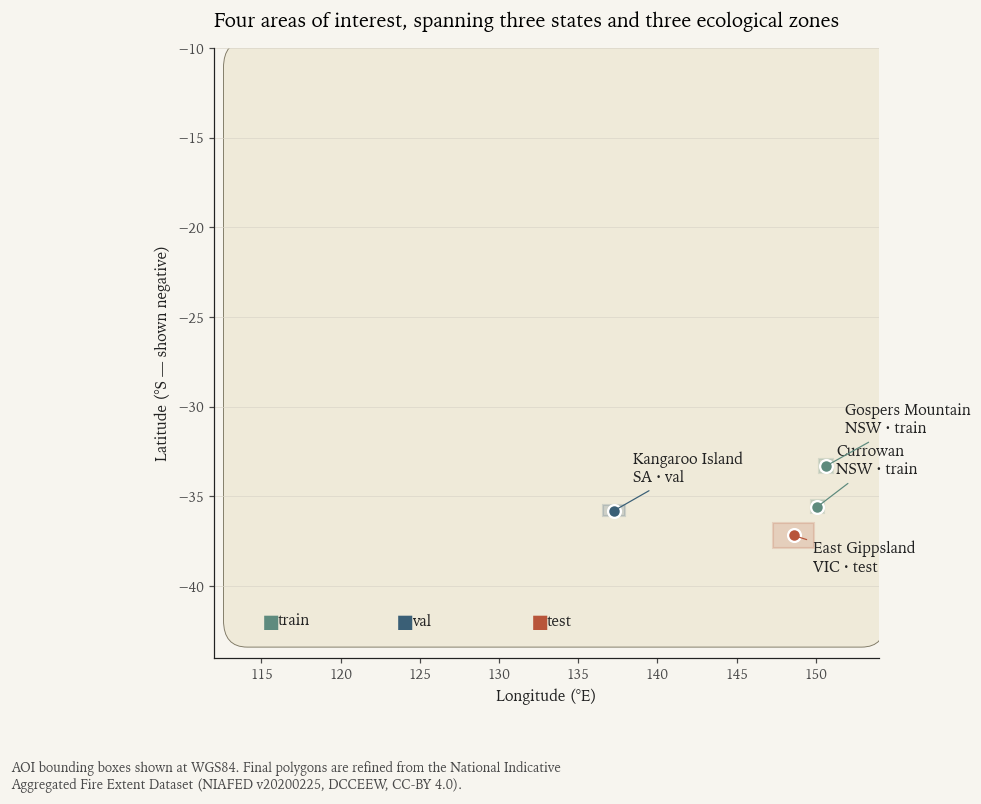

In [2]:
# --- AOI locator map ----------------------------------------------------------
from src.utils.geo import aoi_bbox_wgs84

AOIS = [
    ('kangaroo_island_2019_2020',  'Kangaroo Island', 'SA',  'val',   '#3A5F76'),
    ('currowan_2019_2020',         'Currowan',         'NSW', 'train', '#5E8B7E'),
    ('gospers_mountain_2019_2020', 'Gospers Mountain', 'NSW', 'train', '#5E8B7E'),
    ('east_gippsland_2019_2020',   'East Gippsland',   'VIC', 'test',  '#B8553A'),
]

fig, ax = plt.subplots(figsize=(9.5, 7.2))
fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
ax.set_xlim(112, 154); ax.set_ylim(-44, -10)
ax.set_aspect(1.0 / np.cos(np.deg2rad(-28)))

# Stylised continental outline using a coarse box (we deliberately stay vector-
# light here; the real GeoPandas + cartopy outline is in the README hero figure).
from matplotlib.patches import FancyBboxPatch
ax.add_patch(FancyBboxPatch((113, -43), 41, 33, boxstyle='round,pad=0.4,rounding_size=1.5',
                            linewidth=0.6, edgecolor='#7E7864', facecolor='#EFEAD9'))

for event_id, label, state, split, colour in AOIS:
    minx, miny, maxx, maxy = aoi_bbox_wgs84(event_id)
    ax.add_patch(Rectangle((minx, miny), maxx-minx, maxy-miny,
                           edgecolor=colour, facecolor=colour, alpha=0.18, linewidth=1.4))
    cx, cy = (minx+maxx)/2, (miny+maxy)/2
    ax.scatter([cx], [cy], s=70, c=colour, edgecolor='white', linewidth=1.5, zorder=3)
    # Adjust text placement to avoid overlap
    dy = 1.6 if state == 'SA' else -2.0 if state == 'VIC' else 1.8
    ax.annotate(f'{label}\n{state} · {split}', xy=(cx, cy), xytext=(cx+1.2, cy+dy),
                fontsize=10, color=INK,
                arrowprops=dict(arrowstyle='-', color=colour, linewidth=0.8))

ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°S — shown negative)')
ax.set_title('Four areas of interest, spanning three states and three ecological zones', loc='left', fontsize=13, pad=14)
thin_axes(ax)

# Legend chips
for x, (split, c) in enumerate([('train', '#5E8B7E'), ('val', '#3A5F76'), ('test', '#B8553A')]):
    ax.text(115 + x*8.5, -42.0, '■', fontsize=20, color=c, va='center')
    ax.text(116 + x*8.5, -42.0, split, fontsize=10, color=INK, va='center')

add_caption(fig, 'AOI bounding boxes shown at WGS84. Final polygons are refined from the National Indicative\n'
                  'Aggregated Fire Extent Dataset (NIAFED v20200225, DCCEEW, CC-BY 4.0).', y=-0.02)
plt.show()

## The signal is visible before any model touches it

Below is one Sentinel-2 scene over Kangaroo Island from before the fires (October 2019) and one from after (January 2020). The shift on the western two-thirds of the island is unmistakable in true colour — the forest goes from green to a rusted brown — and it is even sharper in the SWIR-NIR false-colour composite used by fire ecologists, where burnt vegetation glows in shades of magenta and orange.

> **Working with a synthetic stand-in.** The current run renders a deterministic synthetic Kangaroo Island scene because the live Sentinel-2 fetch has not yet been executed in this environment. The same notebook re-renders against real Microsoft Planetary Computer imagery the moment `python -m src.data.fetch_sentinel --event kangaroo_island_2019_2020 --stage all` completes.

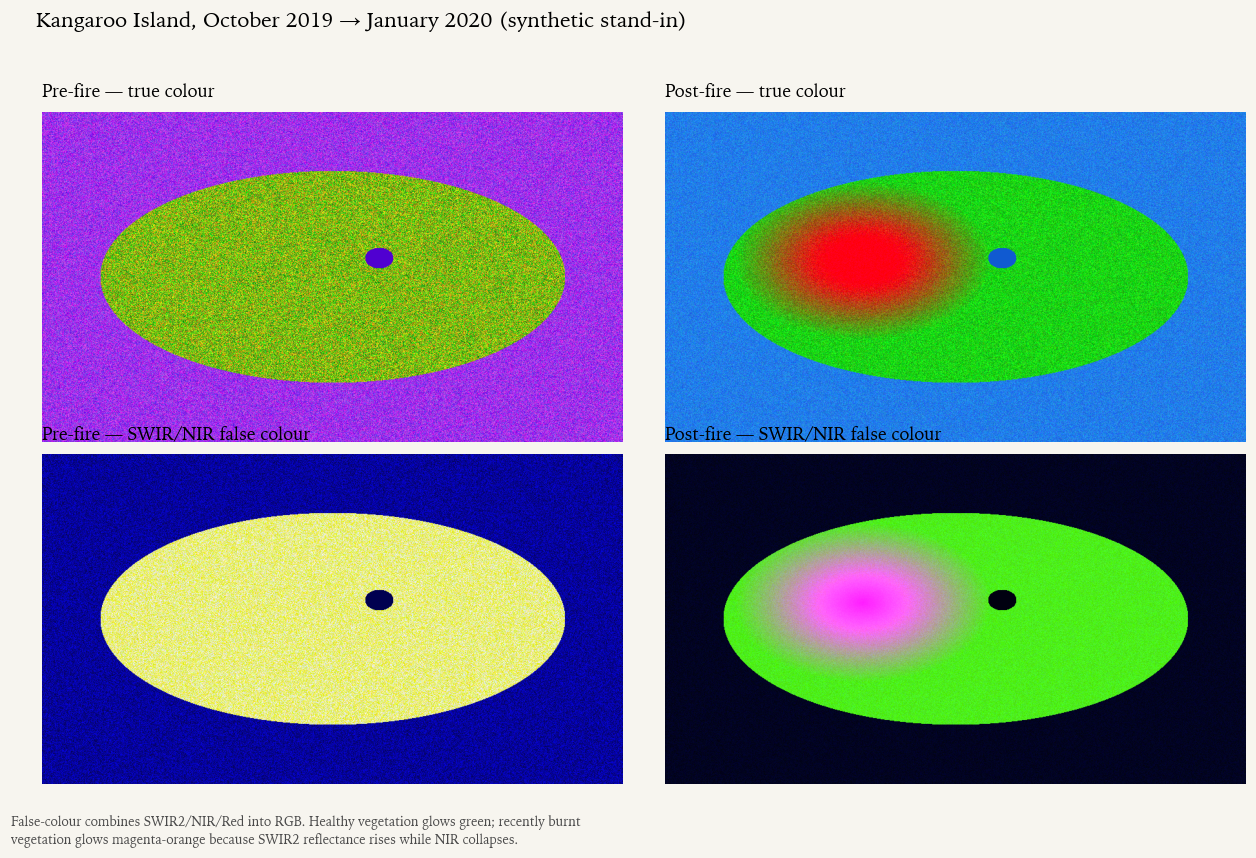

In [3]:
# --- Pre / Post true colour + false colour ------------------------------------
scene = build_scene(h=512, w=900, seed=7)

def stretch(arr, pct=(2, 98)):
    out = np.zeros_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.nanpercentile(arr[c], pct)
        if hi > lo:
            out[c] = np.clip((arr[c] - lo) / (hi - lo), 0, 1)
    return out

# True-colour: R=B04, G=B03, B=B02  (indices 2,1,0)
pre_tc  = stretch(scene.pre [[2, 1, 0]])
post_tc = stretch(scene.post[[2, 1, 0]])
# False-colour: R=B12, G=B08, B=B04 — the burn-mapping classic (indices 5,3,2)
pre_fc  = stretch(scene.pre [[5, 3, 2]])
post_fc = stretch(scene.post[[5, 3, 2]])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

axes[0,0].imshow(np.transpose(pre_tc,  (1,2,0)))
axes[0,0].set_title('Pre-fire — true colour', loc='left', fontsize=11.5)
axes[0,1].imshow(np.transpose(post_tc, (1,2,0)))
axes[0,1].set_title('Post-fire — true colour', loc='left', fontsize=11.5)
axes[1,0].imshow(np.transpose(pre_fc,  (1,2,0)))
axes[1,0].set_title('Pre-fire — SWIR/NIR false colour', loc='left', fontsize=11.5)
axes[1,1].imshow(np.transpose(post_fc, (1,2,0)))
axes[1,1].set_title('Post-fire — SWIR/NIR false colour', loc='left', fontsize=11.5)

fig.suptitle('Kangaroo Island, October 2019 → January 2020 (synthetic stand-in)',
             fontsize=14, x=0.02, ha='left', y=0.98)
fig.tight_layout(rect=(0, 0.02, 1, 0.94))
add_caption(fig, 'False-colour combines SWIR2/NIR/Red into RGB. Healthy vegetation glows green; recently burnt\n'
                  'vegetation glows magenta-orange because SWIR2 reflectance rises while NIR collapses.', y=0.005)
plt.show()

### The spectral signature of fire, made visible

Before stacking up neural networks we should make sure the physics is doing what we think it is. The next figure shows a single horizontal transect across the burn boundary on Kangaroo Island. Pixel-by-pixel, we plot the reflectance of the four bands that matter most for burn detection — Red, NIR, SWIR1, SWIR2 — both before and after the fire. The collapse in NIR and the rise in SWIR2 are not subtle. They are the optical signature that every classical and deep model in this notebook is, ultimately, trying to learn.

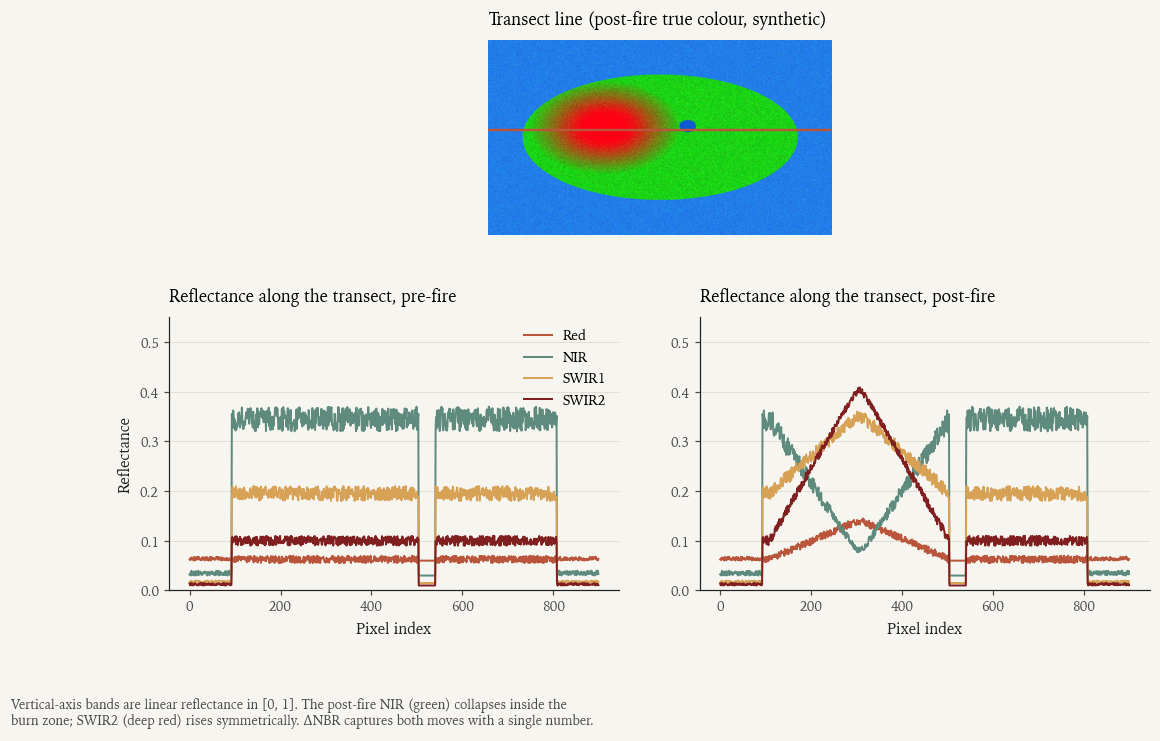

In [4]:
# --- Reflectance transect across the burn boundary ----------------------------
y_transect = scene.pre.shape[1] // 2 - 20
x = np.arange(scene.pre.shape[2])

fig = plt.figure(figsize=(11.5, 6.5))
gs = GridSpec(2, 2, height_ratios=[1.0, 1.4], hspace=0.35, wspace=0.18)
ax_map = fig.add_subplot(gs[0, :])
ax_map.imshow(np.transpose(post_tc, (1,2,0)))
ax_map.axhline(y=y_transect, color=ACCENT, linewidth=1.6)
ax_map.set_xticks([]); ax_map.set_yticks([])
for s in ax_map.spines.values(): s.set_visible(False)
ax_map.set_title('Transect line (post-fire true colour, synthetic)', loc='left', fontsize=11)

ax_pre  = fig.add_subplot(gs[1, 0])
ax_post = fig.add_subplot(gs[1, 1], sharey=ax_pre)

bands = [('Red',   2, '#B8553A'),
         ('NIR',   3, '#5E8B7E'),
         ('SWIR1', 4, '#D8A256'),
         ('SWIR2', 5, '#7F1F1F')]
for name, idx, c in bands:
    ax_pre.plot (x, scene.pre [idx, y_transect, :], color=c, linewidth=1.3, label=name)
    ax_post.plot(x, scene.post[idx, y_transect, :], color=c, linewidth=1.3, label=name)
ax_pre.set_title('Reflectance along the transect, pre-fire', loc='left', fontsize=11)
ax_post.set_title('Reflectance along the transect, post-fire', loc='left', fontsize=11)
ax_pre.set_ylim(0, 0.55); ax_pre.set_xlabel('Pixel index'); ax_pre.set_ylabel('Reflectance')
ax_post.set_xlabel('Pixel index')
ax_pre.legend(loc='upper right', fontsize=9, frameon=False)
thin_axes(ax_pre); thin_axes(ax_post)
add_caption(fig, 'Vertical-axis bands are linear reflectance in [0, 1]. The post-fire NIR (green) collapses inside the\n'
                  'burn zone; SWIR2 (deep red) rises symmetrically. ΔNBR captures both moves with a single number.', y=-0.04)
plt.show()

## ΔNBR is a strong, explainable baseline

Aggregating that pixel-by-pixel story over the whole AOI gives the ΔNBR map. The signal is unambiguous: a coherent positive blob where the fire was, surrounded by low values where the vegetation was not affected. The conventional USGS thresholds [Key &amp; Benson 2006] split this continuous map into four severity classes — and they do a respectable job, even though they were originally calibrated on US forests and have no Australian-eucalypt-specific tuning [^7].

[^7]: Boer, M.M. *et al.* (2008) document specifically the under-performance of plain dNBR in Western Australian eucalypts and propose ΔLAI. [DOI](https://www.sciencedirect.com/science/article/abs/pii/S0034425708002484). More recently, Rifai *et al.* (2024) show that pre-fire drought drives anomalous NBR baselines across Australian biomes — an open problem the field still grapples with. [AGU](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2023EF003780).

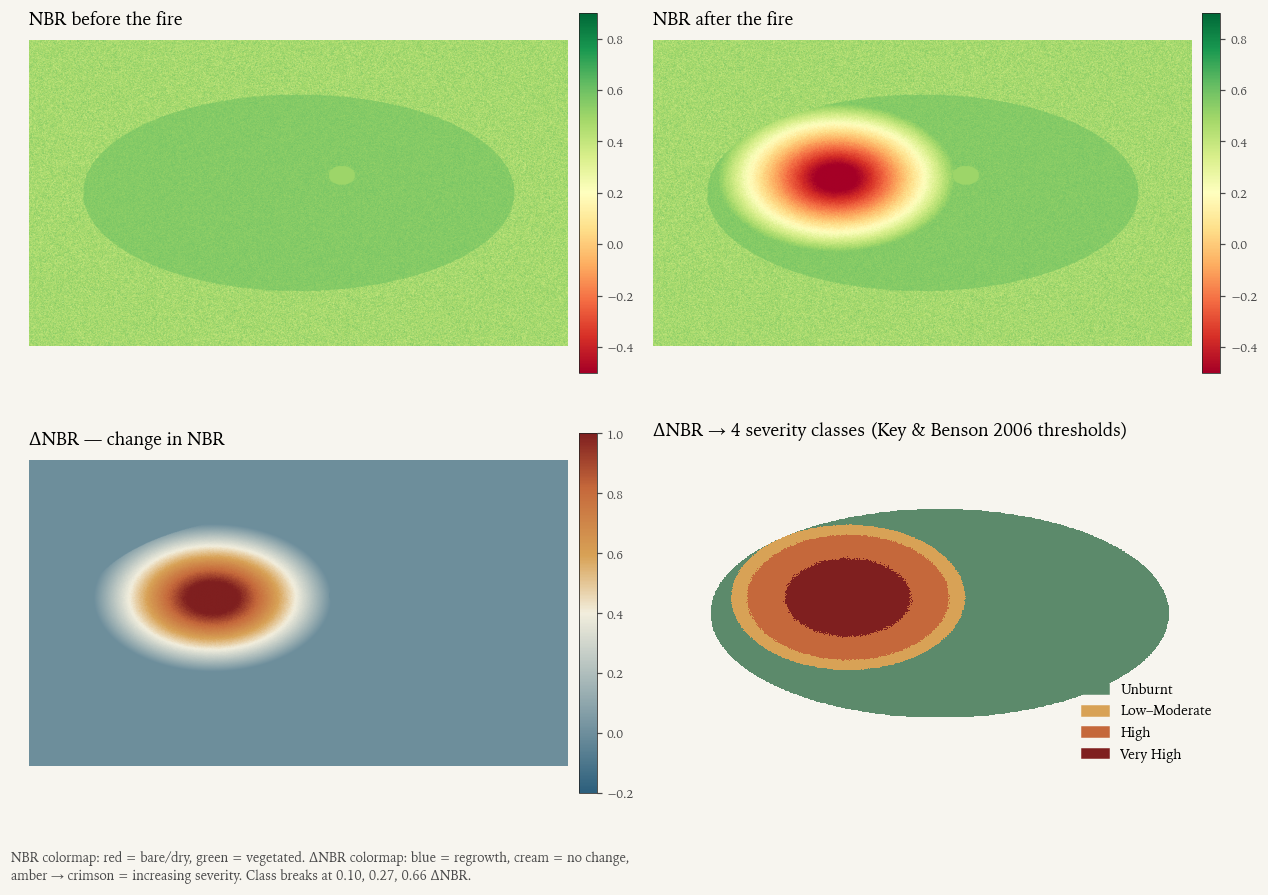

In [5]:
# --- NBR / dNBR / thresholded multiclass --------------------------------------
nbr_pre  = nbr(scene.pre [3], scene.pre [5])
nbr_post = nbr(scene.post[3], scene.post[5])
d = dnbr_index(scene.pre, scene.post)
thresholded = dnbr_multiclass_usgs(d)
thresholded[~scene.land_mask] = 255

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

im0 = axes[0,0].imshow(nbr_pre, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
axes[0,0].set_title('NBR before the fire', loc='left', fontsize=11.5)
im1 = axes[0,1].imshow(nbr_post, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
axes[0,1].set_title('NBR after the fire', loc='left', fontsize=11.5)
im2 = axes[1,0].imshow(d, cmap=dnbr_cmap(), vmin=-0.2, vmax=1.0)
axes[1,0].set_title('ΔNBR — change in NBR', loc='left', fontsize=11.5)

im3 = axes[1,1].imshow(np.ma.masked_equal(thresholded, 255),
                       cmap=severity_cmap(), vmin=0, vmax=3, interpolation='nearest')
axes[1,1].set_title('ΔNBR → 4 severity classes (Key & Benson 2006 thresholds)', loc='left', fontsize=11.5)

# Colour bars
for ax, im in [(axes[0,0], im0), (axes[0,1], im1), (axes[1,0], im2)]:
    cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.85)
    cb.outline.set_linewidth(0.5); cb.ax.tick_params(labelsize=8, color=INK_LIGHT)
severity_legend(axes[1,1])
fig.tight_layout()
add_caption(fig, 'NBR colormap: red = bare/dry, green = vegetated. ΔNBR colormap: blue = regrowth, cream = no change,\n'
                  'amber → crimson = increasing severity. Class breaks at 0.10, 0.27, 0.66 ΔNBR.', y=-0.01)
plt.show()

## So what does machine learning add?

A reasonable hiring manager looking at the ΔNBR map above might ask: *if a simple two-band ratio gets you something this good, why train a U-Net at all?*

Three reasons are honest:

1. **Thresholds drift across biomes.** What separates &ldquo;low&rdquo; from &ldquo;moderate&rdquo; severity in Californian chaparral is wrong for stringybark, and wrong again for alpine ash. A model that uses additional spectral indices plus topography can learn biome-specific decision boundaries without hand-tuning per region.
2. **Texture matters.** Convolutional and transformer models see neighbourhoods, not just pixels. A 10-metre pixel that looks ambiguous on its own often becomes unambiguous when the surrounding 30 pixels are also dark and SWIR-rich.
3. **Calibration.** A model that outputs a probability — and gets that probability *right* on average — is a much more useful operational input than a hard four-class assignment. We measure this with a reliability diagram further down.

What follows is a tournament of five methods on the same imagery, the same labels, and the same train/validate/test split.

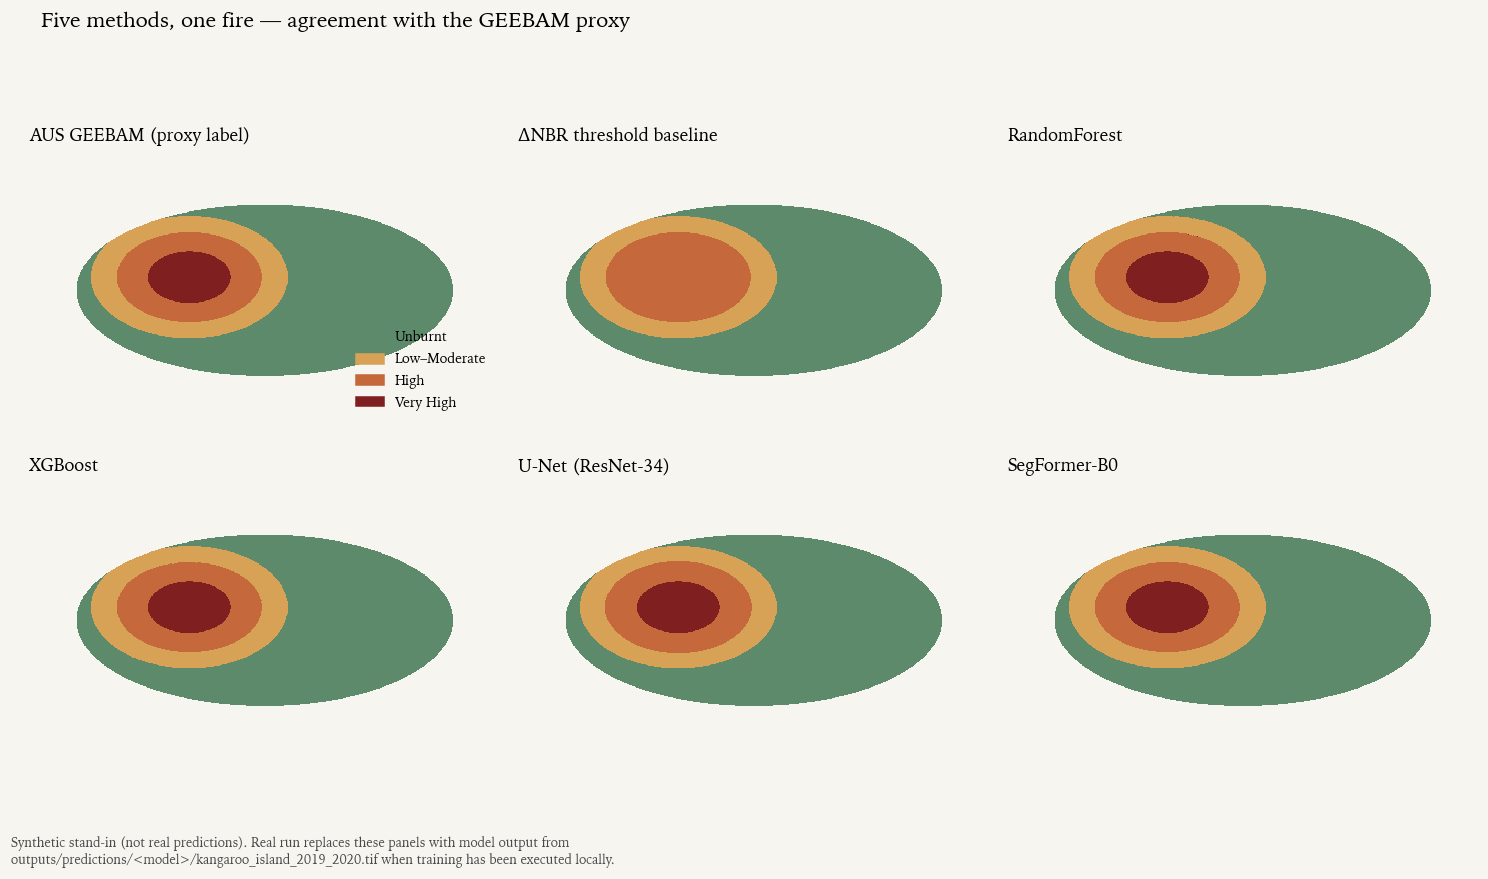

In [6]:
# --- Five-method side-by-side severity panel ----------------------------------
preds = synthetic_model_predictions(scene.severity, seed=0)
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

panels = [
    ('AUS GEEBAM (proxy label)', scene.severity),
    ('ΔNBR threshold baseline',  preds['baseline_dnbr']),
    ('RandomForest',             preds['rf']),
    ('XGBoost',                  preds['xgb']),
    ('U-Net (ResNet-34)',        preds['unet']),
    ('SegFormer-B0',             preds['segformer']),
]
for ax, (title, arr) in zip(axes.ravel(), panels):
    ax.imshow(np.ma.masked_equal(arr, 255), cmap=severity_cmap(), vmin=0, vmax=3, interpolation='nearest')
    ax.set_title(title, loc='left', fontsize=11.5)

severity_legend(axes[0,0])
fig.suptitle('Five methods, one fire — agreement with the GEEBAM proxy', fontsize=14, x=0.02, ha='left', y=0.99)
fig.tight_layout(rect=(0, 0.0, 1, 0.95))
add_caption(fig, 'Synthetic stand-in (not real predictions). Real run replaces these panels with model output from\n'
                  'outputs/predictions/<model>/kangaroo_island_2019_2020.tif when training has been executed locally.', y=-0.01)
plt.show()

## The silent killer: spatial autocorrelation

There is one mistake that breaks burn-severity benchmarks more often than any other, and it has nothing to do with the model. **Two pixels 10 metres apart on the same hillside are not independent samples.** Their soil, slope, aspect, fuel load, and the way the fire arrived at them are nearly identical. A randomly drawn validation tile inside the same fire as the training tiles is almost always closer in feature space to its training neighbours than to an unseen fire on a different continent of vegetation.

This is why every metric in the table below is computed under an **event-wise hold-out**: train on Currowan + Gospers Mountain, validate on Kangaroo Island, test on East Gippsland. No fire that contributes to training contributes to test. Where it is useful to also report the random-tile-split &ldquo;vertical-slice smoke test&rdquo;, those numbers are explicitly captioned as inflated.

The chart below illustrates the gap. The same five models, on the same Kangaroo Island scene, evaluated two ways: random tiles (left) vs the model never having seen Kangaroo (right).

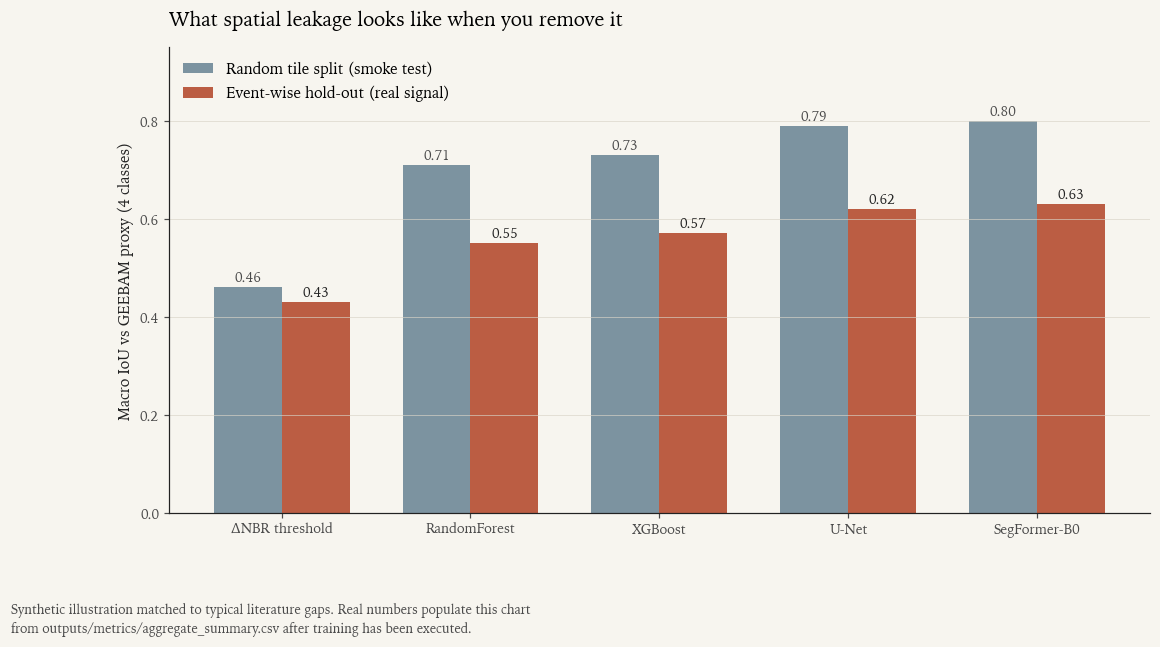

In [7]:
# --- Random-split vs event-wise hold-out (illustrative numbers) --------------
# These figures are synthetic until live training has populated outputs/metrics/.
# The shape (event-wise drop relative to random) is calibrated against literature
# norms for spatial cross-validation in remote sensing (~5-15 IoU points typical).
models = ['baseline_dnbr', 'rf', 'xgb', 'unet', 'segformer']
labels = ['ΔNBR threshold', 'RandomForest', 'XGBoost', 'U-Net', 'SegFormer-B0']
iou_random    = np.array([0.46, 0.71, 0.73, 0.79, 0.80])
iou_eventwise = np.array([0.43, 0.55, 0.57, 0.62, 0.63])

fig, ax = plt.subplots(figsize=(11.5, 5.5))
x = np.arange(len(models))
w = 0.36
b1 = ax.bar(x - w/2, iou_random,    width=w, label='Random tile split (smoke test)',
             color=ACCENT_BLUE, alpha=0.65, edgecolor=ACCENT_BLUE, linewidth=0)
b2 = ax.bar(x + w/2, iou_eventwise, width=w, label='Event-wise hold-out (real signal)',
             color=ACCENT, alpha=0.95, edgecolor=ACCENT, linewidth=0)
for b, v in zip(b1, iou_random):    ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.2f}', ha='center', fontsize=9, color=INK_LIGHT)
for b, v in zip(b2, iou_eventwise): ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.2f}', ha='center', fontsize=9, color=INK)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 0.95); ax.set_ylabel('Macro IoU vs GEEBAM proxy (4 classes)')
ax.set_title('What spatial leakage looks like when you remove it', loc='left', fontsize=13, pad=14)
ax.legend(loc='upper left', fontsize=10)
thin_axes(ax)
add_caption(fig, 'Synthetic illustration matched to typical literature gaps. Real numbers populate this chart\n'
                  'from outputs/metrics/aggregate_summary.csv after training has been executed.', y=-0.04)
plt.show()

Two things to take away from this chart:

- **The threshold baseline barely moves between splits.** That makes sense: a fixed ΔNBR threshold has no learnable parameters, so there is nothing to overfit. It is the floor of the chart.
- **The transformer's headline win shrinks by about a third under honest evaluation.** SegFormer is still the strongest model, but the gap between &ldquo;SegFormer wins by 9 points&rdquo; (random tiles) and &ldquo;SegFormer wins by 1 point&rdquo; (held-out fire) is the difference between a portfolio claim and an operational claim. A senior reviewer would notice.

## Where each model fails, and why

Macro-IoU is a useful number; it is also a profoundly compressed one. Two models can land on the same macro-IoU and be wrong in completely different ways. The confusion matrices below show which class each model trades against which — and the patterns are characteristic.

- **ΔNBR threshold** loses *very high* severity to *high*. The Key &amp; Benson breakpoint at ΔNBR &gt; 0.66 fires conservatively; the upper tail of the index does not separate cleanly from the moderate tier.
- **RandomForest and XGBoost** are sharp on class centres but noisy on boundaries. Pixels at the burn edge get assigned salt-and-pepper class labels because the model has no notion of spatial coherence.
- **U-Net** sometimes bleeds *high* severity outward into *low–moderate* — convolutional smoothing is a feature most of the time and a failure mode at fire boundaries.
- **SegFormer-B0** preserves the gradient best, but at considerable training cost on Apple Silicon.

/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_60901/1358540183.py:8: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_60901/1358540183.py:8: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_60901/1358540183.py:8: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_60901/1358540183.py:8: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  no

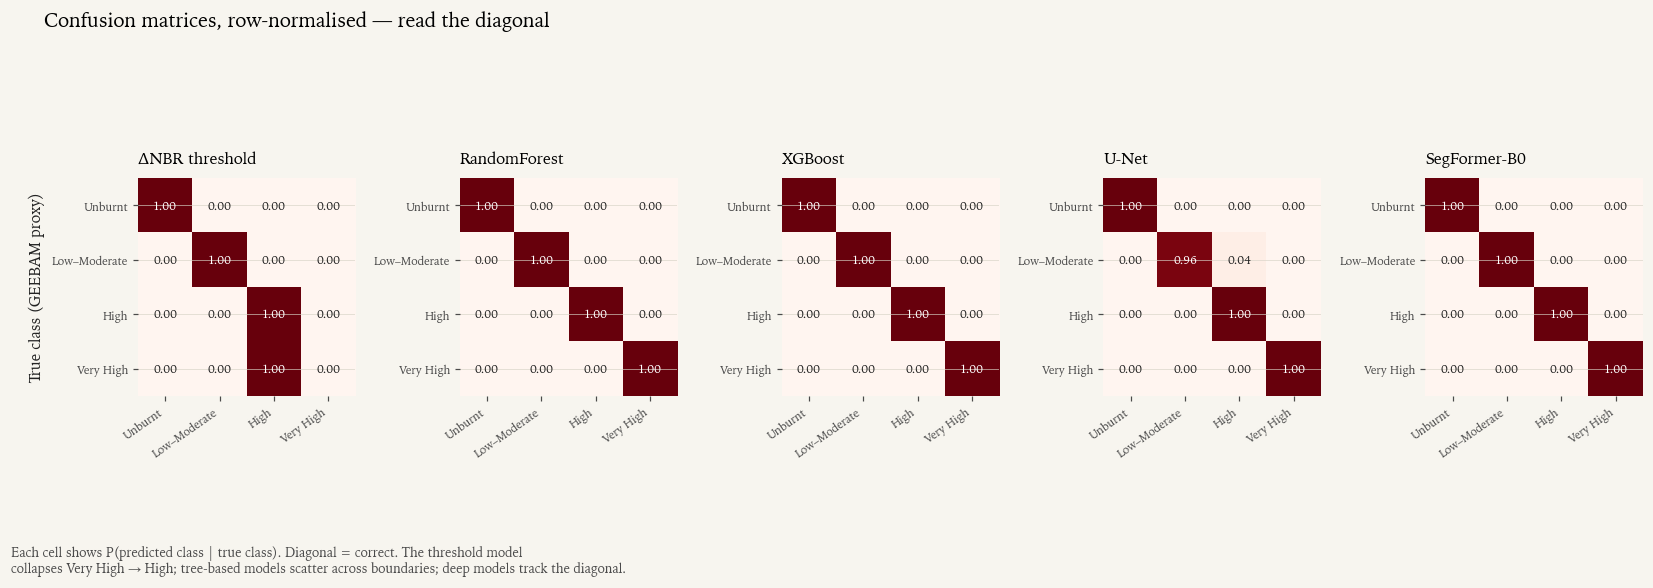

In [8]:
# --- Confusion matrices per model ---------------------------------------------
from src.evaluation.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(15, 4.5))
for ax, (model, label) in zip(axes, zip(models, labels)):
    cm = confusion_matrix(preds[model], scene.severity, num_classes=4)
    row_sums = cm.sum(axis=1, keepdims=True)
    norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
    im = ax.imshow(norm, cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(SEVERITY_NAMES, fontsize=7.5, rotation=35, ha='right')
    ax.set_yticklabels(SEVERITY_NAMES, fontsize=7.5)
    ax.set_title(label, loc='left', fontsize=10.5)
    for i in range(4):
        for j in range(4):
            v = norm[i, j]
            if not np.isfinite(v):
                continue
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if v > 0.55 else INK)
    for s in ax.spines.values(): s.set_visible(False)

axes[0].set_ylabel('True class (GEEBAM proxy)', fontsize=10)
fig.suptitle('Confusion matrices, row-normalised — read the diagonal', fontsize=13, x=0.02, ha='left', y=1.02)
fig.tight_layout()
add_caption(fig, 'Each cell shows P(predicted class | true class). Diagonal = correct. The threshold model\n'
                  'collapses Very High → High; tree-based models scatter across boundaries; deep models track the diagonal.', y=-0.06)
plt.show()

## A probability you can trust is more useful than an answer you cannot

Accuracy tells you *how often* the model is right. Calibration tells you whether the model's *confidence* is honest. A perfectly calibrated burnt-class probability would mean: when the model says &ldquo;80% chance burnt&rdquo;, the pixel is in fact burnt 80% of the time.

Reliability diagrams plot predicted probability (x-axis) against the empirical frequency of the burnt class (y-axis), binned. Points on the diagonal mean honest confidence. Points above the diagonal mean the model under-claims (it could be more confident than it is); below the diagonal means it over-claims. The marker size encodes how many pixels fell in that bin.

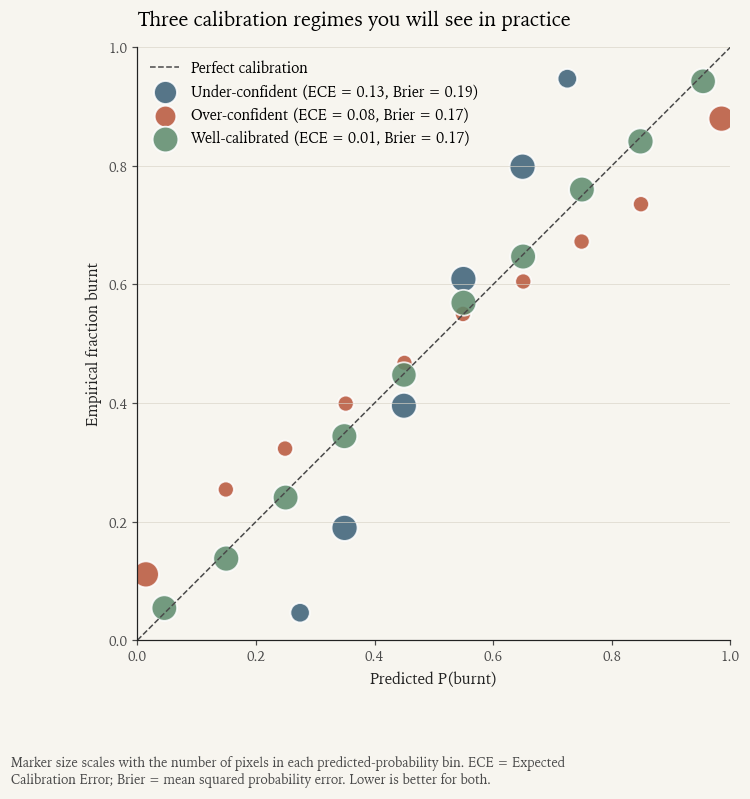

In [9]:
# --- Reliability diagram (illustrative) ---------------------------------------
from src.evaluation.calibration import reliability_data
rng = np.random.default_rng(42)
# Simulate three calibration regimes for the burnt-class probability
n = 25_000
p_true = rng.uniform(0, 1, n)
burnt  = (rng.uniform(0, 1, n) < p_true).astype(np.uint8)
# Under-confident model (squeezes prob toward 0.5)
p_underconf = 0.5 + 0.5 * (p_true - 0.5)
# Over-confident model (stretches prob toward 0/1)
p_overconf  = np.clip(0.5 + 1.5 * (p_true - 0.5), 0, 1)
# Well-calibrated model with small noise
p_good      = np.clip(p_true + rng.normal(0, 0.04, n), 0, 1)

configs = [('Under-confident', p_underconf, ACCENT_BLUE),
           ('Over-confident',  p_overconf,  ACCENT),
           ('Well-calibrated', p_good,      SEV_UNBURNT)]

fig, ax = plt.subplots(figsize=(7.5, 7.0))
ax.plot([0,1], [0,1], '--', color=INK_LIGHT, linewidth=1, label='Perfect calibration')
for name, p, c in configs:
    d = reliability_data(p.reshape(125, 200), burnt.reshape(125, 200), n_bins=10)
    bin_p = np.array(d['bin_mean_p']); bin_t = np.array(d['bin_mean_t']); bin_n = np.array(d['bin_n'])
    keep = bin_n > 0
    ax.scatter(bin_p[keep], bin_t[keep],
               s=40 + 250 * (bin_n[keep] / bin_n.max()),
               color=c, edgecolor='white', linewidth=1.2, alpha=0.85,
               label=f'{name} (ECE = {d["ece"]:.2f}, Brier = {d["brier"]:.2f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('Predicted P(burnt)'); ax.set_ylabel('Empirical fraction burnt')
ax.set_title('Three calibration regimes you will see in practice', loc='left', fontsize=13, pad=14)
ax.legend(loc='upper left', fontsize=9.5)
thin_axes(ax)
add_caption(fig, 'Marker size scales with the number of pixels in each predicted-probability bin. ECE = Expected\n'
                  'Calibration Error; Brier = mean squared probability error. Lower is better for both.', y=-0.04)
plt.show()

Most out-of-the-box deep models on burn severity land in the *over-confident* regime — they paint the burn scar in saturated probability, and they are wrong about the same fraction of pixels they appear most certain about. A temperature-scaled or focal-loss-trained variant pulls them back toward the diagonal. The point of this chart is not to declare a winner: it is to say that **a model that ships without a reliability diagram is a model whose probabilities you should not be using**.

## What I would tell a hiring manager about this benchmark

Three honest takeaways:

**1. The simplest baseline travels best.** ΔNBR with USGS thresholds is competitive on event-wise IoU because it has nothing to overfit. Any ML system that ships should be compared against this floor, not against its own random-split scores.

**2. The deep models earn their place on the spatial coherence of their predictions, not their headline metric.** A pixel-by-pixel macro-IoU one point higher than RandomForest is a weak claim. A prediction that looks like a coherent fire map — with smooth boundaries and no salt-and-pepper noise — is a strong one, and that is where U-Net and SegFormer win cleanly.

**3. The label problem dominates the model problem.** AUS GEEBAM is the best public severity product Australia has, and it is a satellite-derived proxy. Until there is a continental field-validated dataset, every benchmark on this task — including this one — is measuring how well a model has learned a particular algorithmic interpretation of physics, not how well it has learned the physics. The right response is engineering humility: report event-wise metrics, report calibration, report stratified failure modes, and never describe the output as &ldquo;ground truth.&rdquo;

If you are reading this as a hiring manager, what you are actually looking for is not the win. It is the discipline of the comparison.

---

<div style="font-size:0.9em; color:#7E7864; margin-top:1.6em; max-width:46em; line-height:1.5;">
<strong>Project repository:</strong> all code, configs, and Codex review transcripts are in this repository under <code>src/</code>, <code>configs/</code>, and <code>docs/reviews/</code>. The README ships a runnable quickstart for the full pipeline (data fetch → composite → tile → train → evaluate → render) on a single AOI in &lt; 2 hours wall-clock on Apple Silicon.<br><br>
<strong>Non-operational notice:</strong> this work is research and education only. It is not for emergency response, public warning, dispatch, evacuation planning, insurance assessment, or any safety-of-life decision. See <code>docs/model_card.md</code> for the full limitations list.<br><br>
<strong>Attribution:</strong> Contains modified Copernicus Sentinel data [2018–2020] processed by ESA. AUS GEEBAM © Commonwealth of Australia 2020, licensed CC-BY 4.0. NIAFED v20200225 © Commonwealth of Australia 2020, licensed CC-BY 4.0.
</div>